# 08. Turbine Spatial Pooling Feature Lab

공식 `info.xlsx`의 터빈 좌표·KPX 그룹·설비용량과 LDAPS/GFS의 공식 격자 좌표만 사용해 근접(`nearest`)·거리 역가중(`IDW`) pooling을 검증한다. 임의 좌표는 만들지 않으며, 2022~2023만 학습하고 2024를 시간 holdout으로 고정한다.


## 벤치마킹 융합표와 검증 질문

| 근거 | 이번 Lab에서 잠그는 계약 |
|---|---|
| `data_description.md` | `info.xlsx`는 터빈별 좌표·KPX 그룹·용량을 제공하고, LDAPS 16개·GFS 9개 격자는 고정 좌표다. |
| 06 Weather Feature Lab | 전체 격자 mean 및 mean/std/min/max를 동일 RF 조건으로 비교한다. |
| 07 Wind Vector Feature Lab | U/V 파생 뒤 공간 집계하는 vector 319개를 직전 기준선으로 삼는다. |
| 설계 청사진 | 2024 time holdout, prediction만 capacity clip, target별 non-null label mask를 유지한다. |

핵심 질문은 **공식 터빈-격자 관계를 쓰는 pooling이 vector 기준선보다 안정적인 추가 이득을 주는가**이다. 모든 후보는 모델·seed·label mask·metric·clip 조건을 동일하게 둔다.


## 전문가 방법론: 5단계와 증거 사다리

1. 데이터 계약: 원본 hash, 공식 좌표, 그룹·용량, 시간축과 격자 수를 확인한다.
2. 전처리/가공: train geometry에만 fit한 frozen pooler로 raw grid → group → method 순서를 고정한다.
3. 속성 탐색: 거리, nearest 경계, IDW 유효 격자 수, target 상관을 확인한다.
4. 시각화: 터빈·격자·nearest 연결과 IDW 집중도를 함께 본다.
5. 해석/의사결정: 동일 2024 holdout에서 overall 및 target별 6%/8% 안착률까지 비교한다.

증거 순서는 공식 계약 → RED/GREEN → geometry/결측 불변식 → 동일 조건 점수 → 실패 사례 순이다.


In [1]:
from pathlib import Path
import gc
import hashlib
import json
import os
import re
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
  PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
  sys.path.insert(0, str(SRC_DIR))

from baram.baseline import OFFICIAL_RF_PARAMS, calendar_features
from baram.features.turbine_spatial import fit_turbine_spatial_pooler
from baram.features.weather_grid import (
  SPATIAL_STATISTICS,
  WEATHER_METADATA_COLUMNS,
  build_weather_feature_pair,
  fit_train_median_imputer,
)
from baram.features.wind_vector import derive_wind_vector_features
from baram.metrics import CAPACITY_KWH, TARGET_COLS, metric

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "open"
ARTIFACT_ROOTS = [
  PROJECT_ROOT / "outputs",
  PROJECT_ROOT / "submissions",
  PROJECT_ROOT / "models",
]
GUARDED_ARTIFACT_PATTERNS = [
  "*.pkl",
  "*.pickle",
  "*.joblib",
  "*registry*.csv",
  "*submission*.csv",
]

def snapshotArtifactFiles():
  return sorted(
    str(path.relative_to(PROJECT_ROOT)).replace("\\", "/")
    for root in ARTIFACT_ROOTS
    if root.exists()
    for path in root.rglob("*")
    if path.is_file() and path.name != ".gitkeep"
  )

def snapshotGuardedArtifacts():
  guarded = set()
  for pattern in GUARDED_ARTIFACT_PATTERNS:
    for path in PROJECT_ROOT.rglob(pattern):
      relativePath = str(path.relative_to(PROJECT_ROOT)).replace("\\", "/")
      if path.is_file() and not relativePath.startswith("data/raw/open/"):
        guarded.add(relativePath)
  return sorted(guarded)

def schemaSha256(columns):
  payload = json.dumps(list(columns), ensure_ascii=False, separators=(",", ":"))
  return hashlib.sha256(payload.encode("utf-8")).hexdigest()

artifactFilesBefore = snapshotArtifactFiles()
guardedArtifactsBefore = snapshotGuardedArtifacts()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")
display({
  "project_root": str(PROJECT_ROOT),
  "python": sys.version.split()[0],
  "raw_read_only": True,
  "rf_params": OFFICIAL_RF_PARAMS,
  "artifact_files_before": artifactFilesBefore,
  "guarded_artifacts_before": guardedArtifactsBefore,
})


{'project_root': 'C:\\Users\\kik32\\workspace\\baram-2026-wind-power-forecasting',
 'python': '3.12.13',
 'raw_read_only': True,
 'rf_params': {'n_estimators': 120,
  'max_depth': 14,
  'min_samples_leaf': 8,
  'max_features': 'sqrt',
  'random_state': 42,
  'n_jobs': -1},
 'artifact_files_before': [],
 'guarded_artifacts_before': []}

## TDD RED → GREEN 실행 증거

구현 전 `tests/test_turbine_spatial_features.py`에 계약 위반을 먼저 고정했다. stub이던 `fit_turbine_spatial_pooler`를 호출한 26건이 모두 `NotImplementedError`로 실패한 것을 확인한 뒤 최소 구현으로 GREEN을 만들었다.


In [2]:
redEvidence = pd.DataFrame([
  ("입력 계약", "빈 frame·필수 metadata·중복·비숫자 weather", 6),
  ("터빈 계약", "필수 열·ID·group·좌표·용량", 8),
  ("pooling 계약", "method·IDW power·prefix", 4),
  ("geometry 계약", "forecast 및 fit/transform grid·좌표 drift", 3),
  ("수학 계약", "nearest tie·IDW zero·capacity 결합", 3),
  ("결측 계약", "부분 결측 재정규화·전-grid NaN 보존", 2),
], columns=["계약군", "RED 기대", "수집 사례"])
display(redEvidence)
print("RED: python -m pytest tests/test_turbine_spatial_features.py -q --tb=short -p no:cacheprovider")
print("결과: 26 failed in 5.46s (stub NotImplementedError)")
print("GREEN: python -m pytest tests/test_turbine_spatial_features.py -q -p no:cacheprovider")
print("결과: 26 passed in 3.18s")


,계약군,RED 기대,수집 사례
0,입력 계약,빈 frame·필수 metadata·중복·비숫자 weather,6
1,터빈 계약,필수 열·ID·group·좌표·용량,8
2,pooling 계약,method·IDW power·prefix,4
3,geometry 계약,forecast 및 fit/transform grid·좌표 drift,3
4,수학 계약,nearest tie·IDW zero·capacity 결합,3
5,결측 계약,부분 결측 재정규화·전-grid NaN 보존,2


RED: python -m pytest tests/test_turbine_spatial_features.py -q --tb=short -p no:cacheprovider
결과: 26 failed in 5.46s (stub NotImplementedError)
GREEN: python -m pytest tests/test_turbine_spatial_features.py -q -p no:cacheprovider
결과: 26 passed in 3.18s


## 1단계. 데이터 파악: 공식 좌표가 실제로 있는지 먼저 확인

원자료는 읽기만 한다. manifest의 크기·SHA-256을 재검증하고, `info.xlsx`의 병합 셀인 KPX 그룹을 forward-fill한 뒤 DMS 좌표를 십진수로 변환한다. 이 변환은 공식 문자열의 표현만 바꾸며 위치를 추정하지 않는다.


In [3]:
expectedManifest = {
  "data_description.md": (11694, "515ba62cba293e877e20fc993d8e0ff84770f76fa0335debdbd7ed60b9e58819"),
  "info.xlsx": (3823422, "89e83a52e0eb2ce367a3573a96d6795ed4b4d4ac624965cb3530beec0cbd2bd6"),
  "sample_submission.csv": (359229, "c925d2066a834f937f8091ed55acfe50ff86c8be4745b52c3adc95b056c5aaaa"),
  "test/gfs_test.csv": (28037722, "aa33febb24ecd46b82be34880a06910e16a3382319287548e6ce2af721b4f848"),
  "test/ldaps_test.csv": (43122637, "60e94f7cc80384eee335e90dc896b6cf4d36b35cde8d37bc03bd5c08a788b0fa"),
  "train/gfs_train.csv": (84315594, "cd56b67d357e7bbaff5d0d51d3537d935c9e7a3f012e9f37516bdc4d38c66a5d"),
  "train/ldaps_train.csv": (129687357, "61ae944e7ae1fcb17391be6737792a2205c6507bf2446ed5d9d0daf07fdea026"),
  "train/scada_unison_train.csv": (16788646, "5d8ccd7ac6b127865d0b2f18de257ceb23dcbf3b0056c209e8b02f1470c6c9be"),
  "train/scada_vestas_train.csv": (33458140, "f024f3ca57bbe2a6106f515d32c1457d75f519fb27068308680b20fb6f04dcc1"),
  "train/train_labels.csv": (1138967, "47bb64252195cf4734e67394d6e50485f27a608def3b5a8791fcc7674bbceb03"),
}
def sha256File(path):
  digest = hashlib.sha256()
  with path.open("rb") as stream:
    for chunk in iter(lambda: stream.read(1024 * 1024), b""):
      digest.update(chunk)
  return digest.hexdigest()

manifestRows = []
for relativePath, (expectedBytes, expectedSha) in expectedManifest.items():
  path = DATA_ROOT / relativePath
  actualBytes = path.stat().st_size
  actualSha = sha256File(path)
  manifestRows.append({
    "relative_path": relativePath,
    "bytes": actualBytes,
    "size_match": actualBytes == expectedBytes,
    "sha256_match": actualSha == expectedSha,
  })
manifestAudit = pd.DataFrame(manifestRows)
assert manifestAudit[["size_match", "sha256_match"]].all().all()

inputPaths = {
  "train_labels": DATA_ROOT / "train" / "train_labels.csv",
  "ldaps_train": DATA_ROOT / "train" / "ldaps_train.csv",
  "gfs_train": DATA_ROOT / "train" / "gfs_train.csv",
  "ldaps_test": DATA_ROOT / "test" / "ldaps_test.csv",
  "gfs_test": DATA_ROOT / "test" / "gfs_test.csv",
  "sample_submission": DATA_ROOT / "sample_submission.csv",
}
frames = {
  name: pd.read_csv(path, encoding="utf-8-sig")
  for name, path in inputPaths.items()
}
trainLabels = frames["train_labels"].copy()
trainLabels["kst_dtm"] = pd.to_datetime(trainLabels["kst_dtm"], errors="raise")
sampleSubmission = frames["sample_submission"].copy()
sampleSubmission["forecast_kst_dtm"] = pd.to_datetime(
  sampleSubmission["forecast_kst_dtm"], errors="raise"
)

coordinatePattern = re.compile(
  r"(\d+)°(\d+)'([\d.]+)\"([NS])\s+"
  r"(\d+)°(\d+)'([\d.]+)\"([EW])"
)

def parseDmsPair(value):
  match = coordinatePattern.fullmatch(str(value).strip())
  if match is None:
    raise ValueError(f"공식 DMS 좌표 파싱 실패: {value!r}")
  latDegree, latMinute, latSecond, latHemisphere = match.groups()[:4]
  lonDegree, lonMinute, lonSecond, lonHemisphere = match.groups()[4:]
  latitude = float(latDegree) + float(latMinute) / 60 + float(latSecond) / 3600
  longitude = float(lonDegree) + float(lonMinute) / 60 + float(lonSecond) / 3600
  if latHemisphere == "S":
    latitude *= -1
  if lonHemisphere == "W":
    longitude *= -1
  return latitude, longitude

infoRaw = pd.read_excel(DATA_ROOT / "info.xlsx", header=3, usecols="B:L")
officialGroups = infoRaw["KPX그룹"].ffill().astype(int)
parsedCoordinates = infoRaw["좌표(Google)"].map(parseDmsPair)
turbineLocations = pd.DataFrame({
  "turbine_id": (
    infoRaw["제작사"].str.upper()
    + "-"
    + infoRaw["호기"].astype(int).astype(str).str.zfill(2)
  ),
  "group_id": "group_" + officialGroups.astype(str),
  "latitude": parsedCoordinates.map(lambda pair: pair[0]),
  "longitude": parsedCoordinates.map(lambda pair: pair[1]),
  "capacity_mw": pd.to_numeric(infoRaw["설비용량(MW)"], errors="raise"),
})

groupContract = turbineLocations.groupby("group_id", sort=True).agg(
  turbines=("turbine_id", "count"),
  capacity_mw=("capacity_mw", "sum"),
  latitude_min=("latitude", "min"),
  latitude_max=("latitude", "max"),
  longitude_min=("longitude", "min"),
  longitude_max=("longitude", "max"),
).reset_index()
expectedGroupContract = {
  "group_1": (6, 21.6),
  "group_2": (6, 21.6),
  "group_3": (5, 21.0),
}
for row in groupContract.itertuples(index=False):
  assert (row.turbines, round(row.capacity_mw, 1)) == expectedGroupContract[row.group_id]

display(manifestAudit)
display(groupContract)
display(turbineLocations)


,relative_path,bytes,size_match,sha256_match
0,data_description.md,11694,True,True
1,info.xlsx,3823422,True,True
2,sample_submission.csv,359229,True,True
3,test/gfs_test.csv,28037722,True,True
4,test/ldaps_test.csv,43122637,True,True
5,train/gfs_train.csv,84315594,True,True
6,train/ldaps_train.csv,129687357,True,True
7,train/scada_unison_train.csv,16788646,True,True
8,train/scada_vestas_train.csv,33458140,True,True
9,train/train_labels.csv,1138967,True,True


,group_id,turbines,capacity_mw,latitude_min,latitude_max,longitude_min,longitude_max
0,group_1,6,21.6,37.282114,37.291167,128.949542,128.956933
1,group_2,6,21.6,37.275161,37.287833,128.959631,128.967828
2,group_3,5,21.0,37.268564,37.283258,128.962492,128.976578


,turbine_id,group_id,latitude,longitude,capacity_mw
0,VESTAS-01,group_1,37.282114,128.950583,3.6
1,VESTAS-02,group_1,37.284458,128.949542,3.6
2,VESTAS-03,group_1,37.286525,128.949719,3.6
3,VESTAS-04,group_1,37.289753,128.951022,3.6
4,VESTAS-05,group_1,37.291167,128.954328,3.6
5,VESTAS-06,group_1,37.288744,128.956933,3.6
6,VESTAS-07,group_2,37.287833,128.959631,3.6
7,VESTAS-08,group_2,37.286469,128.963122,3.6
8,VESTAS-09,group_2,37.283603,128.965956,3.6
9,VESTAS-10,group_2,37.281325,128.967828,3.6


### 관찰 → 해석 → 다음 판단

- 관찰: 공식 파일 10개가 manifest와 일치하며 `info.xlsx`에 17기 좌표, 그룹, 개별 용량이 있다.
- 해석: 직접적인 spatial pooling이 가능하므로 임의 좌표·가상 배치를 만들 이유가 없다.
- 다음 판단: train/test 격자 좌표가 고정인지, 터빈과 격자의 실제 거리가 pooling을 구분할 만큼 세밀한지 확인한다.


## Decision Box 1. 직접 spatial pooling 가능

**가능**으로 판정한다. 좌표는 `info.xlsx`, grid-to-turbine 관계는 공식 터빈·격자 좌표의 haversine 거리로 결정한다. 그룹 출력은 개별 터빈 pooling을 설비용량으로 결합한다. 좌표가 없는 경우의 대안(격자 통계·row order 기반 실험)은 이번 데이터에서는 사용하지 않는다.


## 2단계. 거리 계약: 격자 해상도와 경계 민감도

거리 분석은 pooling 구현과 독립적으로 다시 계산한다. `nearest`는 최소 거리 grid, IDW는 각 터빈의 역거리 가중치를 그룹 용량으로 결합한다. 유효 격자 수는 `1 / Σw²`로 측정한다.


In [4]:
weatherFrames = {
  name: frames[name]
  for name in ["ldaps_train", "gfs_train", "ldaps_test", "gfs_test"]
}

sourceRows = []
missingRows = []
for frameName, frame in weatherFrames.items():
  source = frameName.split("_")[0]
  forecast = pd.to_datetime(frame["forecast_kst_dtm"], errors="raise")
  available = pd.to_datetime(frame["data_available_kst_dtm"], errors="raise")
  grouped = pd.DataFrame({
    "forecast": forecast,
    "grid_id": frame["grid_id"],
    "lead": (forecast - available).dt.total_seconds().div(3600),
  }).groupby("forecast", sort=True)
  counterpart = frames[f"{source}_{'test' if frameName.endswith('train') else 'train'}"]
  sourceRows.append({
    "frame": frameName,
    "rows": len(frame),
    "forecast_rows": forecast.nunique(),
    "grid_min": grouped["grid_id"].nunique().min(),
    "grid_max": grouped["grid_id"].nunique().max(),
    "lead_min": grouped["lead"].first().min(),
    "lead_max": grouped["lead"].first().max(),
    "cutoff_violations": int((available > forecast).sum()),
    "train_test_schema_equal": list(frame.columns) == list(counterpart.columns),
  })
  valueColumns = [
    column for column in frame.columns
    if column not in WEATHER_METADATA_COLUMNS
    and pd.api.types.is_numeric_dtype(frame[column])
    and not pd.api.types.is_bool_dtype(frame[column])
  ]
  availableCounts = frame.assign(
    forecast_kst_dtm=forecast
  ).groupby("forecast_kst_dtm")[valueColumns].count()
  expectedGridCount = 16 if source == "ldaps" else 9
  missingRows.append({
    "frame": frameName,
    "all_grid_missing_forecast_variables": int(availableCounts.eq(0).sum().sum()),
    "partial_grid_missing_forecast_variables": int(
      ((availableCounts > 0) & (availableCounts < expectedGridCount)).sum().sum()
    ),
  })
sourceAudit = pd.DataFrame(sourceRows)
missingAudit = pd.DataFrame(missingRows)
assert sourceAudit["cutoff_violations"].eq(0).all()
assert sourceAudit["train_test_schema_equal"].all()

def haversineMatrix(turbines, grids):
  earthRadiusKm = 6371.0088
  turbineLat = np.radians(turbines["latitude"].to_numpy(dtype=float))[:, None]
  turbineLon = np.radians(turbines["longitude"].to_numpy(dtype=float))[:, None]
  gridLat = np.radians(grids["latitude"].to_numpy(dtype=float))[None, :]
  gridLon = np.radians(grids["longitude"].to_numpy(dtype=float))[None, :]
  latDelta = gridLat - turbineLat
  lonDelta = gridLon - turbineLon
  value = (
    np.sin(latDelta / 2) ** 2
    + np.cos(turbineLat) * np.cos(gridLat) * np.sin(lonDelta / 2) ** 2
  )
  return earthRadiusKm * 2 * np.arcsin(np.sqrt(np.clip(value, 0, 1)))

geometryBySource = {}
distanceBySource = {}
nearestRows = []
effectiveRows = []
for source in ["ldaps", "gfs"]:
  grids = (
    frames[f"{source}_train"][["grid_id", "latitude", "longitude"]]
    .drop_duplicates()
    .sort_values("grid_id")
    .reset_index(drop=True)
  )
  assert grids["grid_id"].nunique() == len(grids)
  geometryBySource[source] = grids
  distances = haversineMatrix(turbineLocations, grids)
  distanceBySource[source] = distances
  ordered = np.sort(distances, axis=1)
  nearestIndex = distances.argmin(axis=1)
  for turbineIndex, turbine in turbineLocations.iterrows():
    gridIndex = nearestIndex[turbineIndex]
    nearestRows.append({
      "source": source,
      "turbine_id": turbine["turbine_id"],
      "group_id": turbine["group_id"],
      "nearest_grid_id": grids.iloc[gridIndex]["grid_id"],
      "nearest_km": distances[turbineIndex, gridIndex],
      "second_gap_km": ordered[turbineIndex, 1] - ordered[turbineIndex, 0],
    })
  for power in [1.0, 2.0]:
    turbineWeights = np.power(distances.min(axis=1, keepdims=True) / distances, power)
    turbineWeights /= turbineWeights.sum(axis=1, keepdims=True)
    for groupId, groupTurbines in turbineLocations.groupby("group_id", sort=True):
      indices = groupTurbines.index.to_numpy()
      capacities = groupTurbines["capacity_mw"].to_numpy(dtype=float, copy=True)
      capacities /= capacities.sum()
      groupWeights = capacities @ turbineWeights[indices]
      effectiveRows.append({
        "source": source,
        "group_id": groupId,
        "idw_power": power,
        "effective_grid_count": 1.0 / np.square(groupWeights).sum(),
        "maximum_grid_weight": groupWeights.max(),
      })

nearestAudit = pd.DataFrame(nearestRows)
effectiveGridAudit = pd.DataFrame(effectiveRows)
nearestSummary = nearestAudit.groupby(["source", "group_id"], sort=True).agg(
  turbines=("turbine_id", "count"),
  unique_nearest_grids=("nearest_grid_id", "nunique"),
  nearest_km_min=("nearest_km", "min"),
  nearest_km_max=("nearest_km", "max"),
  minimum_boundary_gap_km=("second_gap_km", "min"),
).reset_index()
nearestCounts = nearestAudit.groupby(
  ["source", "group_id", "nearest_grid_id"], sort=True
).size().rename("turbines").reset_index()
assert nearestAudit.query("source == 'gfs'")["nearest_grid_id"].nunique() == 1
assert missingAudit.set_index("frame").loc[
  "ldaps_test", "all_grid_missing_forecast_variables"
] == 47
assert missingAudit["partial_grid_missing_forecast_variables"].eq(0).all()
display(sourceAudit)
display(missingAudit)
display(nearestSummary)
display(nearestCounts)
display(effectiveGridAudit)


,frame,rows,forecast_rows,grid_min,grid_max,lead_min,lead_max,cutoff_violations,train_test_schema_equal
0,ldaps_train,420864,26304,16,16,12.0,35.0,0,True
1,gfs_train,236736,26304,9,9,12.0,35.0,0,True
2,ldaps_test,140160,8760,16,16,12.0,35.0,0,True
3,gfs_test,78840,8760,9,9,12.0,35.0,0,True


,frame,all_grid_missing_forecast_variables,partial_grid_missing_forecast_variables
0,ldaps_train,0,0
1,gfs_train,0,0
2,ldaps_test,47,0
3,gfs_test,0,0


,source,group_id,turbines,unique_nearest_grids,nearest_km_min,nearest_km_max,minimum_boundary_gap_km
0,gfs,group_1,6,1,5.645759,6.190502,12.109600
1,gfs,group_2,6,1,4.020574,5.518959,13.502142
2,gfs,group_3,5,1,2.925374,4.969246,14.194766
3,ldaps,group_1,6,3,0.359815,0.995511,0.018013
4,ldaps,group_2,6,2,0.161960,0.962576,0.064920
5,ldaps,group_3,5,2,0.402894,0.747951,0.201787


,source,group_id,nearest_grid_id,turbines
0,gfs,group_1,5.0,6
1,gfs,group_2,5.0,6
2,gfs,group_3,5.0,5
3,ldaps,group_1,5.0,3
4,ldaps,group_1,6.0,2
5,ldaps,group_1,10.0,1
6,ldaps,group_2,6.0,3
7,ldaps,group_2,11.0,3
8,ldaps,group_3,6.0,1
9,ldaps,group_3,12.0,4


,source,group_id,idw_power,effective_grid_count,maximum_grid_weight
0,ldaps,group_1,1.0,11.800052,0.158109
1,ldaps,group_2,1.0,10.619641,0.209885
2,ldaps,group_3,1.0,11.272289,0.194999
3,ldaps,group_1,2.0,5.742349,0.290122
4,ldaps,group_2,2.0,4.674308,0.395343
5,ldaps,group_3,2.0,4.726232,0.411595
6,gfs,group_1,1.0,5.146248,0.377527
7,gfs,group_2,1.0,4.328632,0.434438
8,gfs,group_3,1.0,3.602103,0.493876
9,gfs,group_1,2.0,1.820575,0.733197


### 관찰 → 해석 → 다음 판단

- LDAPS는 그룹마다 2~3개 nearest grid를 사용하고 최근접 거리가 약 0.16~1.00 km다. 다만 VESTAS-01은 1·2순위 차이가 약 0.018 km라 nearest 경계에 민감하다.
- GFS는 모든 터빈이 동일 grid 5를 최근접으로 선택한다. 따라서 GFS nearest는 그룹 공간 구분력이 없고, IDW의 주변 grid 혼합만 차이를 만든다.
- test LDAPS의 47개 forecast-variable은 16개 grid가 모두 결측이며 부분 결측은 없다. pooling은 이 값을 NaN으로 보존하고 이후 train-fit median만 적용해야 한다.


## Decision Box 2. 비교 후보와 누수 차단

- `nearest`: 해석이 단순한 경계 민감 후보.
- `IDW p=1`: 넓게 혼합하는 완만한 후보.
- `IDW p=2`: 가까운 격자를 더 강조하는 주 후보.
- `all-group`: 각 target 모델에 세 그룹 공간 문맥을 모두 제공한다.
- `own-group`: target에 대응하는 그룹 77개만 추가해 차원 증가 의존성을 확인한다.

가중치는 **2022~2023 train grid geometry + 공식 터빈 좌표·용량**에만 fit한다. weather 값, 2024 label, test 값은 가중치 결정에 사용하지 않는다.


## 3단계. 전처리/가공: raw grid → wind vector → group spatial pooling

06/07과 동일하게 mean-only 74, expanded 271, vector 319를 재구성한다. 공간 후보는 vector 319에 method별 231개(all-group) 또는 77개(own-group)를 붙인다. 출력 열 순서는 raw feature → group → method로 고정한다.


In [5]:
vectorFrames = {
  name: derive_wind_vector_features(frame, source=name.split("_")[0])
  for name, frame in weatherFrames.items()
}
officialPair = build_weather_feature_pair(
  frames["ldaps_train"],
  frames["gfs_train"],
  frames["ldaps_test"],
  frames["gfs_test"],
  statistics=("mean",),
  include_lead=False,
  std_ddof=0,
)
expandedPair = build_weather_feature_pair(
  frames["ldaps_train"],
  frames["gfs_train"],
  frames["ldaps_test"],
  frames["gfs_test"],
  statistics=SPATIAL_STATISTICS,
  include_lead=True,
  std_ddof=0,
)
vectorPair = build_weather_feature_pair(
  vectorFrames["ldaps_train"],
  vectorFrames["gfs_train"],
  vectorFrames["ldaps_test"],
  vectorFrames["gfs_test"],
  statistics=SPATIAL_STATISTICS,
  include_lead=True,
  std_ddof=0,
)

def fitFrame(frame):
  forecast = pd.to_datetime(frame["forecast_kst_dtm"], errors="raise")
  return frame.loc[forecast.dt.year < 2024].copy()

poolersP2 = {
  source: fit_turbine_spatial_pooler(
    fitFrame(vectorFrames[f"{source}_train"]),
    turbineLocations,
    source=source,
    pooling_methods=("nearest", "idw"),
    idw_power=2.0,
  )
  for source in ["ldaps", "gfs"]
}
poolersP1 = {
  source: fit_turbine_spatial_pooler(
    fitFrame(vectorFrames[f"{source}_train"]),
    turbineLocations,
    source=source,
    pooling_methods=("idw",),
    idw_power=1.0,
  )
  for source in ["ldaps", "gfs"]
}

def mergeSpatialFeatures(ldapsFeatures, gfsFeatures):
  return ldapsFeatures.merge(
    gfsFeatures,
    on="forecast_kst_dtm",
    how="inner",
    sort=True,
    validate="one_to_one",
  )

spatialP2Train = mergeSpatialFeatures(
  poolersP2["ldaps"].transform(vectorFrames["ldaps_train"]),
  poolersP2["gfs"].transform(vectorFrames["gfs_train"]),
)
spatialP2Test = mergeSpatialFeatures(
  poolersP2["ldaps"].transform(vectorFrames["ldaps_test"]),
  poolersP2["gfs"].transform(vectorFrames["gfs_test"]),
)
spatialP1Train = mergeSpatialFeatures(
  poolersP1["ldaps"].transform(vectorFrames["ldaps_train"]),
  poolersP1["gfs"].transform(vectorFrames["gfs_train"]),
)
spatialP1Test = mergeSpatialFeatures(
  poolersP1["ldaps"].transform(vectorFrames["ldaps_test"]),
  poolersP1["gfs"].transform(vectorFrames["gfs_test"]),
)

def buildModelMatrix(timeSeries, weatherFeatures):
  base = pd.DataFrame({"forecast_kst_dtm": pd.to_datetime(timeSeries)})
  merged = base.merge(
    weatherFeatures,
    on="forecast_kst_dtm",
    how="left",
    sort=False,
    validate="one_to_one",
  )
  if len(merged) != len(base):
    raise ValueError("시간축과 weather feature 행 수가 다릅니다")
  return pd.concat([
    calendar_features(merged["forecast_kst_dtm"]),
    merged.drop(columns=["forecast_kst_dtm"]),
  ], axis=1)

def buildSpatialMatrix(timeSeries, spatialFeatures):
  base = pd.DataFrame({"forecast_kst_dtm": pd.to_datetime(timeSeries)})
  merged = base.merge(
    spatialFeatures,
    on="forecast_kst_dtm",
    how="left",
    sort=False,
    validate="one_to_one",
  )
  if len(merged) != len(base):
    raise ValueError("시간축과 spatial feature 행 수가 다릅니다")
  return merged.drop(columns=["forecast_kst_dtm"])

baseTrainMatrices = {
  "official_mean": buildModelMatrix(trainLabels["kst_dtm"], officialPair.train),
  "expanded_spatial": buildModelMatrix(trainLabels["kst_dtm"], expandedPair.train),
  "expanded_plus_vector": buildModelMatrix(trainLabels["kst_dtm"], vectorPair.train),
}
baseTestMatrices = {
  "official_mean": buildModelMatrix(sampleSubmission["forecast_kst_dtm"], officialPair.test),
  "expanded_spatial": buildModelMatrix(sampleSubmission["forecast_kst_dtm"], expandedPair.test),
  "expanded_plus_vector": buildModelMatrix(sampleSubmission["forecast_kst_dtm"], vectorPair.test),
}
spatialTrainMatrices = {
  "p2": buildSpatialMatrix(trainLabels["kst_dtm"], spatialP2Train),
  "p1": buildSpatialMatrix(trainLabels["kst_dtm"], spatialP1Train),
}
spatialTestMatrices = {
  "p2": buildSpatialMatrix(sampleSubmission["forecast_kst_dtm"], spatialP2Test),
  "p1": buildSpatialMatrix(sampleSubmission["forecast_kst_dtm"], spatialP1Test),
}

featureDefinitions = {
  "official_mean": {"base": "official_mean"},
  "expanded_spatial": {"base": "expanded_spatial"},
  "expanded_plus_vector": {"base": "expanded_plus_vector"},
  "vector_plus_nearest_all": {"base": "expanded_plus_vector", "pool": "p2", "method": "nearest", "scope": "all"},
  "vector_plus_idw_p1_all": {"base": "expanded_plus_vector", "pool": "p1", "method": "idw", "scope": "all"},
  "vector_plus_idw_p2_all": {"base": "expanded_plus_vector", "pool": "p2", "method": "idw", "scope": "all"},
  "vector_plus_nearest_own": {"base": "expanded_plus_vector", "pool": "p2", "method": "nearest", "scope": "own"},
  "vector_plus_idw_p2_own": {"base": "expanded_plus_vector", "pool": "p2", "method": "idw", "scope": "own"},
}

def spatialColumns(definition, target):
  if "pool" not in definition:
    return []
  sourceColumns = spatialTrainMatrices[definition["pool"]].columns
  methodSuffix = f"_{definition['method']}"
  columns = [column for column in sourceColumns if column.endswith(methodSuffix)]
  if definition["scope"] == "own":
    groupId = target.removeprefix("kpx_")
    columns = [column for column in columns if f"_{groupId}_" in column]
  return columns

def featureColumns(featureSet, target):
  definition = featureDefinitions[featureSet]
  return [
    *baseTrainMatrices[definition["base"]].columns,
    *spatialColumns(definition, target),
  ]

def matrixFor(featureSet, target, split):
  definition = featureDefinitions[featureSet]
  baseMatrices = baseTrainMatrices if split == "train" else baseTestMatrices
  resultParts = [baseMatrices[definition["base"]]]
  if "pool" in definition:
    spatialMatrices = spatialTrainMatrices if split == "train" else spatialTestMatrices
    resultParts.append(
      spatialMatrices[definition["pool"]].loc[:, spatialColumns(definition, target)]
    )
  result = pd.concat(resultParts, axis=1)
  if result.columns.duplicated().any():
    raise ValueError(f"중복 feature: {featureSet}, {target}")
  return result

forecastYear = trainLabels["kst_dtm"].dt.year
modelTrainMask = forecastYear < 2024
holdoutMask = forecastYear == 2024
boundaryExcludedMask = forecastYear > 2024
assert (int(modelTrainMask.sum()), int(holdoutMask.sum()), int(boundaryExcludedMask.sum())) == (17519, 8784, 1)
assert [baseTrainMatrices[name].shape[1] for name in baseTrainMatrices] == [74, 271, 319]

schemaRows = []
for featureSet in featureDefinitions:
  for target in TARGET_COLS:
    columns = featureColumns(featureSet, target)
    schemaRows.append({
      "feature_set": featureSet,
      "target": target,
      "feature_count": len(columns),
      "schema_sha256": schemaSha256(columns),
    })
featureSchema = pd.DataFrame(schemaRows)
expectedFeatureCounts = {
  "official_mean": 74,
  "expanded_spatial": 271,
  "expanded_plus_vector": 319,
  "vector_plus_nearest_all": 550,
  "vector_plus_idw_p1_all": 550,
  "vector_plus_idw_p2_all": 550,
  "vector_plus_nearest_own": 396,
  "vector_plus_idw_p2_own": 396,
}
assert all(
  featureSchema.query("feature_set == @featureSet")["feature_count"].eq(expectedCount).all()
  for featureSet, expectedCount in expectedFeatureCounts.items()
)
display(featureSchema)
display({
  "pooler_fit_scope": "2022-2023 train geometry only",
  "weights_use_weather_values": False,
  "weights_use_labels": False,
  "p2_train_missing": int(spatialTrainMatrices["p2"].isna().sum().sum()),
  "p2_test_missing": int(spatialTestMatrices["p2"].isna().sum().sum()),
})


,feature_set,target,feature_count,schema_sha256
0,official_mean,kpx_group_1,74,7165ab3f8b117f90d9bbc033b2d3247bcf48d098938320...
1,official_mean,kpx_group_2,74,7165ab3f8b117f90d9bbc033b2d3247bcf48d098938320...
2,official_mean,kpx_group_3,74,7165ab3f8b117f90d9bbc033b2d3247bcf48d098938320...
3,expanded_spatial,kpx_group_1,271,5b0331b62b8e88562ed7a1b5505043b1d41edffafb2104...
4,expanded_spatial,kpx_group_2,271,5b0331b62b8e88562ed7a1b5505043b1d41edffafb2104...
5,expanded_spatial,kpx_group_3,271,5b0331b62b8e88562ed7a1b5505043b1d41edffafb2104...
6,expanded_plus_vector,kpx_group_1,319,f5f3b9eb20fabffedf47eac1e95202df8ff1d14d0be5f4...
7,expanded_plus_vector,kpx_group_2,319,f5f3b9eb20fabffedf47eac1e95202df8ff1d14d0be5f4...
8,expanded_plus_vector,kpx_group_3,319,f5f3b9eb20fabffedf47eac1e95202df8ff1d14d0be5f4...
9,vector_plus_nearest_all,kpx_group_1,550,7ba0915a4c8a8e2017dcc6cd6d9fcdfa085358982d242b...


{'pooler_fit_scope': '2022-2023 train geometry only',
 'weights_use_weather_values': False,
 'weights_use_labels': False,
 'p2_train_missing': 0,
 'p2_test_missing': 282}

### 관찰 → 해석 → 다음 판단

- 세 기준선 74/271/319와 공간 후보 550/396의 schema가 예상과 일치한다.
- pooler는 geometry와 metadata만 fit하며 transform의 raw schema·grid ID·좌표가 달라지면 즉시 실패한다.
- all-grid 결측은 spatial feature에서도 NaN으로 남았다. 이 값은 다음 단계에서 2022~2023 train median으로만 보정한다.


## 4단계. 속성 탐색: 거리 가중치가 실제로 다른 정보를 만드는가

nearest와 IDW의 group별 풍속 피처를 target과 연결해 상관 방향을 확인한다. 상관은 인과나 채택 기준이 아니라, 공간 변환이 단순 복제인지 확인하는 보조 증거다.


In [6]:
spatialPropertyFrame = trainLabels.rename(
  columns={"kst_dtm": "forecast_kst_dtm"}
).merge(
  spatialP2Train,
  on="forecast_kst_dtm",
  how="left",
  validate="one_to_one",
)
propertyRows = []
for target in TARGET_COLS:
  groupId = target.removeprefix("kpx_")
  for source, height in [("ldaps", "10m"), ("gfs", "100m")]:
    for method in ["nearest", "idw"]:
      feature = f"{source}_windvec_{height}_speed_{groupId}_{method}"
      propertyRows.append({
        "target": target,
        "source": source,
        "height": height,
        "method": method,
        "feature_std": spatialPropertyFrame[feature].std(),
        "corr_target": spatialPropertyFrame[[feature, target]].corr().iloc[0, 1],
      })
propertyAudit = pd.DataFrame(propertyRows)
targetAvailability = pd.DataFrame([
  {
    "target": target,
    "train_non_null": int(trainLabels.loc[modelTrainMask, target].notna().sum()),
    "holdout_non_null": int(trainLabels.loc[holdoutMask, target].notna().sum()),
    "holdout_metric_rows": int((
      trainLabels.loc[holdoutMask, target] >= CAPACITY_KWH[target] * 0.10
    ).sum()),
  }
  for target in TARGET_COLS
])
gfsNearestFeatures = [
  column for column in spatialP2Train.columns
  if column.startswith("gfs_") and column.endswith("_nearest")
]
gfsDuplicateGroups = pd.DataFrame([
  {
    "raw_feature": column.rsplit("_group_", 1)[0],
    "group_1_equals_group_2": bool(np.array_equal(
      spatialP2Train[column].to_numpy(),
      spatialP2Train[column.replace("_group_1_", "_group_2_")].to_numpy(),
      equal_nan=True,
    )),
    "group_1_equals_group_3": bool(np.array_equal(
      spatialP2Train[column].to_numpy(),
      spatialP2Train[column.replace("_group_1_", "_group_3_")].to_numpy(),
      equal_nan=True,
    )),
  }
  for column in gfsNearestFeatures
  if "_group_1_" in column
])
assert gfsDuplicateGroups[["group_1_equals_group_2", "group_1_equals_group_3"]].all().all()
display(propertyAudit)
display(targetAvailability)
display({
  "gfs_nearest_raw_features": len(gfsDuplicateGroups),
  "all_group_nearest_values_identical": True,
})


,target,source,height,method,feature_std,corr_target
0,kpx_group_1,ldaps,10m,nearest,2.419409,0.665594
1,kpx_group_1,ldaps,10m,idw,2.434064,0.700743
2,kpx_group_1,gfs,100m,nearest,3.165436,0.617837
3,kpx_group_1,gfs,100m,idw,2.968724,0.611822
4,kpx_group_2,ldaps,10m,nearest,2.506175,0.747459
5,kpx_group_2,ldaps,10m,idw,2.530729,0.758337
6,kpx_group_2,gfs,100m,nearest,3.165436,0.628410
7,kpx_group_2,gfs,100m,idw,3.025560,0.624737
8,kpx_group_3,ldaps,10m,nearest,2.709855,0.775472
9,kpx_group_3,ldaps,10m,idw,2.628335,0.765563


,target,train_non_null,holdout_non_null,holdout_metric_rows
0,kpx_group_1,17421,8778,4989
1,kpx_group_2,17422,8778,4976
2,kpx_group_3,8759,8778,4566


{'gfs_nearest_raw_features': 44, 'all_group_nearest_values_identical': True}

### 관찰 → 해석 → 다음 판단

GFS nearest의 세 그룹 값은 모든 raw feature에서 동일하다. 반면 LDAPS nearest와 양 source의 IDW는 그룹별 가중치가 달라진다. 따라서 성능 이득은 LDAPS의 국지 관계와 GFS 주변 격자 혼합에서 나오는지 holdout으로 판정해야 한다.


## 5단계. 시각화: 터빈-격자 연결과 IDW 집중도

왼쪽은 공식 좌표와 nearest 연결, 오른쪽은 IDW power별 유효 격자 수다. 좌표축은 지역 비교용이며 지도 투영을 가장하지 않는다.


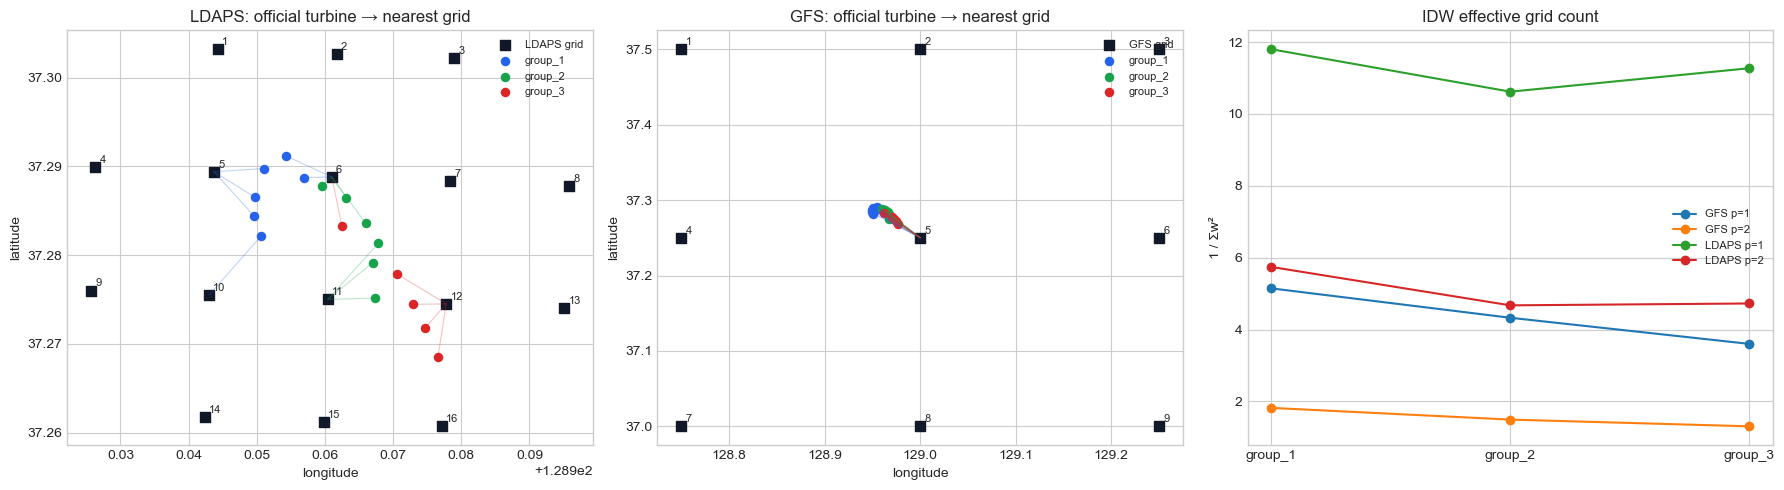

In [7]:
groupColors = {"group_1": "#2563eb", "group_2": "#16a34a", "group_3": "#dc2626"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, source in zip(axes[:2], ["ldaps", "gfs"]):
  grids = geometryBySource[source]
  axis.scatter(
    grids["longitude"], grids["latitude"],
    marker="s", s=55, color="#111827", label=f"{source.upper()} grid",
  )
  for row in grids.itertuples(index=False):
    axis.annotate(str(row.grid_id), (row.longitude, row.latitude), xytext=(3, 3), textcoords="offset points", fontsize=8)
  nearestSource = nearestAudit.query("source == @source").set_index("turbine_id")
  gridLookup = grids.set_index("grid_id")
  for groupId, groupFrame in turbineLocations.groupby("group_id", sort=True):
    axis.scatter(
      groupFrame["longitude"], groupFrame["latitude"],
      s=34, color=groupColors[groupId], label=groupId,
    )
    for turbine in groupFrame.itertuples(index=False):
      gridId = nearestSource.loc[turbine.turbine_id, "nearest_grid_id"]
      grid = gridLookup.loc[gridId]
      axis.plot(
        [turbine.longitude, grid["longitude"]],
        [turbine.latitude, grid["latitude"]],
        color=groupColors[groupId], alpha=0.28, linewidth=0.8,
      )
  axis.set_title(f"{source.upper()}: official turbine → nearest grid")
  axis.set_xlabel("longitude")
  axis.set_ylabel("latitude")
  axis.legend(fontsize=8)

for (source, power), frame in effectiveGridAudit.groupby(["source", "idw_power"], sort=True):
  label = f"{source.upper()} p={power:g}"
  axes[2].plot(
    frame["group_id"], frame["effective_grid_count"], marker="o", label=label,
  )
axes[2].set_title("IDW effective grid count")
axes[2].set_ylabel("1 / Σw²")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()


### 관찰 → 해석 → 다음 판단

LDAPS 연결은 그룹별로 갈라지지만 GFS 연결은 한 점으로 모인다. IDW p=2의 유효 격자 수는 LDAPS 약 4.7~5.7개, GFS 약 1.3~1.8개로 p=1보다 국지적이다. nearest 단독과 p=1/p=2를 모두 점수로 확인한다.


## 동일 조건 2024 time holdout

`year < 2024` 17,519행만 imputer와 RF 학습에 사용하고 2024 8,784행을 검증한다. 2025 경계 1행은 제외한다. label 결측은 0으로 바꾸지 않고 target별 non-null mask를 사용한다. actual은 복사 후 hash를 유지하고 prediction만 `[0, capacity]`로 clip한다.


In [8]:
validActualOriginal = trainLabels.loc[holdoutMask, TARGET_COLS].copy(deep=True)
actualHashBefore = hashlib.sha256(
  pd.util.hash_pandas_object(validActualOriginal, index=True).to_numpy().tobytes()
).hexdigest()

validationPredictions = {}
overallRows = []
imputerRows = []
trainRowRecords = []
for featureSet, definition in featureDefinitions.items():
  started = time.perf_counter()
  predictions = pd.DataFrame(index=validActualOriginal.index)
  ownScope = definition.get("scope") == "own"
  commonTrain = None
  commonHoldout = None
  commonTest = None
  commonImputer = None
  if not ownScope:
    fullX = matrixFor(featureSet, TARGET_COLS[0], "train")
    testX = matrixFor(featureSet, TARGET_COLS[0], "test")
    commonImputer = fit_train_median_imputer(fullX.loc[modelTrainMask])
    commonTrain = commonImputer.transform(fullX.loc[modelTrainMask])
    commonHoldout = commonImputer.transform(fullX.loc[holdoutMask])
    commonTest = commonImputer.transform(testX)
    imputerRows.append({
      "feature_set": featureSet,
      "target": "shared",
      "fit_rows": int(modelTrainMask.sum()),
      "fit_scope": "2022-2023 train only",
      "test_missing_before": int(testX.isna().sum().sum()),
      "test_missing_after": int(commonTest.isna().sum().sum()),
    })
    del fullX, testX, commonTest

  for target in TARGET_COLS:
    if ownScope:
      fullX = matrixFor(featureSet, target, "train")
      testX = matrixFor(featureSet, target, "test")
      fittedImputer = fit_train_median_imputer(fullX.loc[modelTrainMask])
      transformedTrain = fittedImputer.transform(fullX.loc[modelTrainMask])
      transformedHoldout = fittedImputer.transform(fullX.loc[holdoutMask])
      transformedTest = fittedImputer.transform(testX)
      imputerRows.append({
        "feature_set": featureSet,
        "target": target,
        "fit_rows": int(modelTrainMask.sum()),
        "fit_scope": "2022-2023 train only",
        "test_missing_before": int(testX.isna().sum().sum()),
        "test_missing_after": int(transformedTest.isna().sum().sum()),
      })
      del transformedTest, fullX, testX
    else:
      transformedTrain = commonTrain
      transformedHoldout = commonHoldout

    targetLabels = trainLabels.loc[modelTrainMask, target]
    targetNonNull = targetLabels.notna()
    model = RandomForestRegressor(**dict(OFFICIAL_RF_PARAMS))
    model.fit(
      transformedTrain.loc[targetNonNull],
      targetLabels.loc[targetNonNull],
    )
    rawPrediction = model.predict(transformedHoldout)
    predictions[target] = np.clip(rawPrediction, 0, CAPACITY_KWH[target])
    trainRowRecords.append({
      "feature_set": featureSet,
      "target": target,
      "non_null_train_rows": int(targetNonNull.sum()),
      "zero_filled_labels": 0,
    })
    del model
    if ownScope:
      del fittedImputer, transformedTrain, transformedHoldout

  totalScore, oneMinusNmae, ficr = metric(validActualOriginal, predictions)
  validationPredictions[featureSet] = predictions
  overallRows.append({
    "feature_set": featureSet,
    "feature_count": expectedFeatureCounts[featureSet],
    "train_rows": int(modelTrainMask.sum()),
    "holdout_rows": int(holdoutMask.sum()),
    "total_score": float(totalScore),
    "one_minus_nmae": float(oneMinusNmae),
    "ficr": float(ficr),
    "fit_predict_seconds": time.perf_counter() - started,
  })
  if not ownScope:
    del commonImputer, commonTrain, commonHoldout
  gc.collect()

actualHashAfter = hashlib.sha256(
  pd.util.hash_pandas_object(validActualOriginal, index=True).to_numpy().tobytes()
).hexdigest()
overallScoreboard = pd.DataFrame(overallRows).set_index("feature_set")
imputerAudit = pd.DataFrame(imputerRows)
trainRowAudit = pd.DataFrame(trainRowRecords)
assert actualHashBefore == actualHashAfter
assert imputerAudit["test_missing_after"].eq(0).all()
assert trainRowAudit["zero_filled_labels"].eq(0).all()
assert trainRowAudit.groupby("target")["non_null_train_rows"].nunique().eq(1).all()
display(overallScoreboard)
display(imputerAudit)
display(trainRowAudit.pivot(index="target", columns="feature_set", values="non_null_train_rows"))
print({"actual_unchanged": actualHashBefore == actualHashAfter})


,feature_count,train_rows,holdout_rows,total_score,one_minus_nmae,ficr,fit_predict_seconds
feature_set,,,,,,,
official_mean,74,17519,8784,0.576938,0.863228,0.290647,2.272278
expanded_spatial,271,17519,8784,0.585265,0.867325,0.303204,5.128509
expanded_plus_vector,319,17519,8784,0.586482,0.867895,0.305070,5.498777
vector_plus_nearest_all,550,17519,8784,0.591249,0.869399,0.313099,7.804091
vector_plus_idw_p1_all,550,17519,8784,0.590010,0.868738,0.311283,8.365989
vector_plus_idw_p2_all,550,17519,8784,0.592485,0.869565,0.315406,7.816707
vector_plus_nearest_own,396,17519,8784,0.589828,0.868767,0.310890,7.977864
vector_plus_idw_p2_own,396,17519,8784,0.589269,0.868836,0.309701,8.540572


,feature_set,target,fit_rows,fit_scope,test_missing_before,test_missing_after
0,official_mean,shared,17519,2022-2023 train only,47,0
1,expanded_spatial,shared,17519,2022-2023 train only,188,0
2,expanded_plus_vector,shared,17519,2022-2023 train only,188,0
3,vector_plus_nearest_all,shared,17519,2022-2023 train only,329,0
4,vector_plus_idw_p1_all,shared,17519,2022-2023 train only,329,0
5,vector_plus_idw_p2_all,shared,17519,2022-2023 train only,329,0
6,vector_plus_nearest_own,kpx_group_1,17519,2022-2023 train only,235,0
7,vector_plus_nearest_own,kpx_group_2,17519,2022-2023 train only,235,0
8,vector_plus_nearest_own,kpx_group_3,17519,2022-2023 train only,235,0
9,vector_plus_idw_p2_own,kpx_group_1,17519,2022-2023 train only,235,0


feature_set,expanded_plus_vector,expanded_spatial,official_mean,vector_plus_idw_p1_all,vector_plus_idw_p2_all,vector_plus_idw_p2_own,vector_plus_nearest_all,vector_plus_nearest_own
target,,,,,,,,
kpx_group_1,17421,17421,17421,17421,17421,17421,17421,17421
kpx_group_2,17422,17422,17422,17422,17422,17422,17422,17422
kpx_group_3,8759,8759,8759,8759,8759,8759,8759,8759


{'actual_unchanged': True}


### 관찰 → 해석 → 다음 판단

all-group IDW p=2가 total score·1-NMAE·FICR 모두 최고다. nearest all-group도 세 지표를 개선해 거리 경계의 국지성이 유효하지만, 정산 구간 안착까지 합치면 p=2가 우세하다. own-group 후보도 vector보다 개선되므로 이득이 다른 그룹 열을 추가한 차원 효과에만 의존하지 않는다.


In [9]:
def targetScoreRows(featureSet, actualFrame, predictionFrame):
  rows = []
  for target in TARGET_COLS:
    capacity = CAPACITY_KWH[target]
    actual = actualFrame[target].to_numpy(dtype=float)
    prediction = predictionFrame[target].to_numpy(dtype=float)
    valid = np.isfinite(actual) & (actual >= capacity * 0.10)
    errorRate = np.abs(prediction[valid] - actual[valid]) / capacity
    unitPrice = np.select(
      [errorRate <= 0.06, errorRate <= 0.08],
      [4.0, 3.0],
      default=0.0,
    )
    rows.append({
      "feature_set": featureSet,
      "target": target,
      "metric_rows": int(valid.sum()),
      "nmae": float(errorRate.mean()),
      "ficr": float(np.sum(actual[valid] * unitPrice) / np.sum(actual[valid] * 4.0)),
      "landing_6pct": float((errorRate <= 0.06).mean()),
      "landing_8pct": float((errorRate <= 0.08).mean()),
    })
  return rows

targetScoreboard = pd.DataFrame([
  row
  for featureSet, predictions in validationPredictions.items()
  for row in targetScoreRows(featureSet, validActualOriginal, predictions)
])
vectorName = "expanded_plus_vector"
primaryName = "vector_plus_idw_p2_all"
leanName = "vector_plus_nearest_own"
metricColumns = ["total_score", "one_minus_nmae", "ficr"]
overallDeltas = pd.DataFrame({
  candidate: overallScoreboard.loc[candidate, metricColumns]
  - overallScoreboard.loc[vectorName, metricColumns]
  for candidate in [
    "vector_plus_nearest_all",
    "vector_plus_idw_p1_all",
    primaryName,
    leanName,
    "vector_plus_idw_p2_own",
  ]
}).T
targetPivot = targetScoreboard.set_index(["feature_set", "target"])
targetDeltaRows = []
for candidate in [primaryName, leanName]:
  for target in TARGET_COLS:
    for measure in ["nmae", "ficr", "landing_6pct", "landing_8pct"]:
      targetDeltaRows.append({
        "candidate": candidate,
        "target": target,
        "measure": measure,
        "delta_vs_vector": (
          targetPivot.loc[(candidate, target), measure]
          - targetPivot.loc[(vectorName, target), measure]
        ),
      })
targetDeltas = pd.DataFrame(targetDeltaRows)
primaryTargetDeltas = targetDeltas.query("candidate == @primaryName")
assert overallDeltas.loc[primaryName, "total_score"] > 0
assert primaryTargetDeltas.query("measure == 'nmae'")["delta_vs_vector"].lt(0).all()
assert primaryTargetDeltas.query("measure == 'ficr'")["delta_vs_vector"].gt(0).all()
assert primaryTargetDeltas.query("measure == 'landing_6pct'")["delta_vs_vector"].gt(0).all()
assert targetDeltas.query(
  "candidate == @primaryName and target == 'kpx_group_3' and measure == 'landing_8pct'"
)["delta_vs_vector"].iloc[0] < 0
display(overallDeltas)
display(targetScoreboard)
display(targetDeltas)
print({
  "primary_candidate": primaryName,
  "total_score": overallScoreboard.loc[primaryName, "total_score"],
  "delta_vs_vector": overallDeltas.loc[primaryName, "total_score"],
  "lean_candidate": leanName,
  "lean_delta_vs_vector": overallDeltas.loc[leanName, "total_score"],
})


,total_score,one_minus_nmae,ficr
vector_plus_nearest_all,0.004767,0.001504,0.008029
vector_plus_idw_p1_all,0.003528,0.000843,0.006213
vector_plus_idw_p2_all,0.006003,0.001670,0.010336
vector_plus_nearest_own,0.003346,0.000872,0.005820
vector_plus_idw_p2_own,0.002786,0.000941,0.004631


,feature_set,target,metric_rows,nmae,ficr,landing_6pct,landing_8pct
0,official_mean,kpx_group_1,4989,0.129808,0.277974,0.283223,0.377430
1,official_mean,kpx_group_2,4976,0.128420,0.352206,0.306069,0.401929
2,official_mean,kpx_group_3,4566,0.152087,0.241762,0.260841,0.345817
3,expanded_spatial,kpx_group_1,4989,0.126971,0.282609,0.286631,0.380437
4,expanded_spatial,kpx_group_2,4976,0.124087,0.373646,0.323955,0.422830
5,expanded_spatial,kpx_group_3,4566,0.146965,0.253357,0.268287,0.360053
6,expanded_plus_vector,kpx_group_1,4989,0.126590,0.284206,0.285628,0.381840
7,expanded_plus_vector,kpx_group_2,4976,0.124307,0.373853,0.321141,0.422428
8,expanded_plus_vector,kpx_group_3,4566,0.145419,0.257152,0.276610,0.364871
9,vector_plus_nearest_all,kpx_group_1,4989,0.124993,0.297681,0.292243,0.392463


,candidate,target,measure,delta_vs_vector
0,vector_plus_idw_p2_all,kpx_group_1,nmae,-0.002162
1,vector_plus_idw_p2_all,kpx_group_1,ficr,0.016650
2,vector_plus_idw_p2_all,kpx_group_1,landing_6pct,0.013229
3,vector_plus_idw_p2_all,kpx_group_1,landing_8pct,0.008619
4,vector_plus_idw_p2_all,kpx_group_2,nmae,-0.001154
5,vector_plus_idw_p2_all,kpx_group_2,ficr,0.009957
6,vector_plus_idw_p2_all,kpx_group_2,landing_6pct,0.005024
7,vector_plus_idw_p2_all,kpx_group_2,landing_8pct,0.002412
8,vector_plus_idw_p2_all,kpx_group_3,nmae,-0.001695
9,vector_plus_idw_p2_all,kpx_group_3,ficr,0.004401


{'primary_candidate': 'vector_plus_idw_p2_all', 'total_score': 0.5924854297224146, 'delta_vs_vector': 0.006002949852530692, 'lean_candidate': 'vector_plus_nearest_own', 'lean_delta_vs_vector': 0.0033458901465431845}


### 관찰 → 해석 → 다음 판단

- 주 후보 p=2 all-group는 vector 대비 total `+0.006003`, FICR `+0.010336`이며 세 target의 NMAE·FICR·6% 안착률이 모두 개선된다.
- 축소 대안 own-nearest도 396개로 total `+0.003346`과 세 target NMAE 개선을 유지한다.
- 단, Group 3의 8% 안착률은 주 후보에서도 약 `-0.000438` 하락한다. 단일 holdout의 overall 상승만으로 무조건 승격하지 않고 실패 사례를 함께 잠근다.


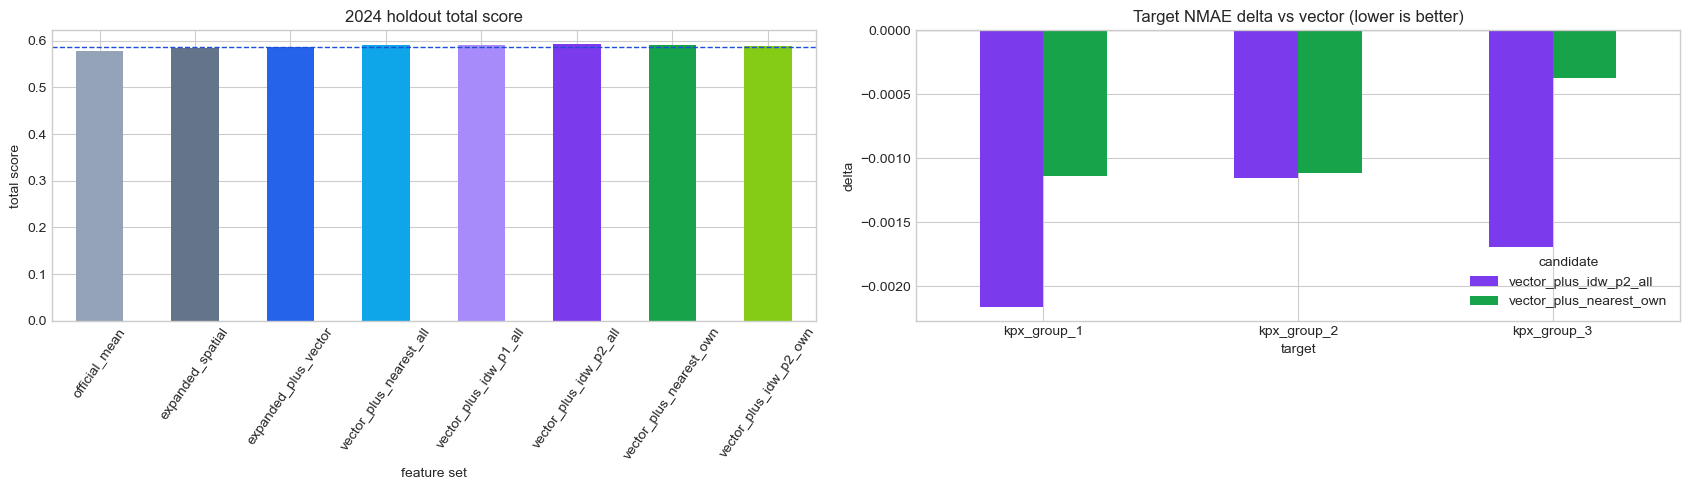

In [10]:
candidateOrder = list(featureDefinitions)
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
overallScoreboard.loc[candidateOrder, "total_score"].plot.bar(
  ax=axes[0],
  color=["#94a3b8", "#64748b", "#2563eb", "#0ea5e9", "#a78bfa", "#7c3aed", "#16a34a", "#84cc16"],
)
axes[0].axhline(
  overallScoreboard.loc[vectorName, "total_score"], color="#1d4ed8", linestyle="--", linewidth=1,
)
axes[0].set_title("2024 holdout total score")
axes[0].set_xlabel("feature set")
axes[0].set_ylabel("total score")
axes[0].tick_params(axis="x", rotation=55)

plotDeltas = targetDeltas.query("measure == 'nmae'").pivot(
  index="target", columns="candidate", values="delta_vs_vector"
)
plotDeltas.plot.bar(ax=axes[1], color=["#7c3aed", "#16a34a"])
axes[1].axhline(0, color="#111827", linewidth=0.8)
axes[1].set_title("Target NMAE delta vs vector (lower is better)")
axes[1].set_xlabel("target")
axes[1].set_ylabel("delta")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 실패 사례와 강건성 해석

| 실패/제약 | 관찰 | 영향과 처리 |
|---|---|---|
| GFS 해상도 | 17기 모두 grid 5가 nearest | GFS nearest의 그룹 구분력 없음; IDW 주변 혼합만 후보로 해석 |
| LDAPS 경계 | VESTAS-01의 1·2순위 거리 차이 약 18 m | nearest는 좌표/격자 경계 민감; IDW와 함께 비교 |
| 전-grid 결측 | LDAPS test 47 forecast-variable pair | NaN 보존 후 2022~2023 train median만 적용 |
| Group 3 | p=2 all-group의 8% 안착률 소폭 하락 | overall 개선과 별도로 후속 시간 fold에서 재검증 |
| 단일 holdout | 2024 한 구간 | DACON 규칙에 맞지만 계절별 안정성을 보장하지 않음 |


In [11]:
validationCommands = [
  (
    "focused_pytest",
    [sys.executable, "-m", "pytest", "tests/test_turbine_spatial_features.py", "-q", "-p", "no:cacheprovider"],
  ),
  (
    "full_pytest",
    [sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
  ),
]
validationRows = []
pytestTempRoot = PROJECT_ROOT / "temp" / f"notebook08-pytest-{os.getpid()}"
pytestTempRoot.parent.mkdir(parents=True, exist_ok=True)
for checkName, command in validationCommands:
  completed = subprocess.run(
    command,
    cwd=PROJECT_ROOT,
    capture_output=True,
    env={
      **os.environ,
      "PYTHONIOENCODING": "utf-8",
      "PYTHONUTF8": "1",
      "TEMP": str(pytestTempRoot.parent),
      "TMP": str(pytestTempRoot.parent),
      "PYTEST_ADDOPTS": f"--basetemp={pytestTempRoot.as_posix()}",
    },
    text=True,
    encoding="utf-8",
    errors="replace",
    timeout=1800,
    check=False,
  )
  combinedOutput = ((completed.stdout or "") + (completed.stderr or "")).strip().splitlines()
  validationRows.append({
    "check": checkName,
    "returncode": completed.returncode,
    "last_line": combinedOutput[-1] if combinedOutput else "",
  })
validationResults = pd.DataFrame(validationRows)
if pytestTempRoot.exists():
  shutil.rmtree(pytestTempRoot)
if pytestTempRoot.parent.exists() and not any(pytestTempRoot.parent.iterdir()):
  pytestTempRoot.parent.rmdir()

artifactFilesAfter = snapshotArtifactFiles()
guardedArtifactsAfter = snapshotGuardedArtifacts()
newGuardedArtifacts = sorted(set(guardedArtifactsAfter) - set(guardedArtifactsBefore))
filesWritten = artifactFilesAfter != artifactFilesBefore or bool(newGuardedArtifacts)
memoryContract = pd.DataFrame([
  {
    "candidate_count": len(featureDefinitions),
    "predictions_retained_in_memory": len(validationPredictions),
    "models_retained_after_scoring": 0,
    "registry_csv_written": any("registry" in path.lower() and path.lower().endswith(".csv") for path in newGuardedArtifacts),
    "model_file_written": any(path.lower().endswith((".pkl", ".pickle", ".joblib")) for path in newGuardedArtifacts),
    "submission_csv_written": any("submission" in path.lower() and path.lower().endswith(".csv") for path in newGuardedArtifacts),
  }
])
assert validationResults["returncode"].eq(0).all()
assert not filesWritten
display(validationResults)
display(memoryContract)
print({
  "artifact_files_before": artifactFilesBefore,
  "artifact_files_after": artifactFilesAfter,
  "new_guarded_artifacts": newGuardedArtifacts,
  "files_written": filesWritten,
})


,check,returncode,last_line
0,focused_pytest,0,[32m[32m[1m26 passed[0m[32m in 2.32s[0m[0m
1,full_pytest,0,[32m[32m[1m105 passed[0m[32m in 9.76s[0m...


,candidate_count,predictions_retained_in_memory,models_retained_after_scoring,registry_csv_written,model_file_written,submission_csv_written
0,8,8,0,False,False,False


{'artifact_files_before': [], 'artifact_files_after': [], 'new_guarded_artifacts': [], 'files_written': False}


## Final Decision Box

**검증 결론: all-group IDW p=2를 주 후보로 채택한다.**

- vector 319: total `0.586482`, 1-NMAE `0.867895`, FICR `0.305070`
- IDW p=2 all-group 550: total `0.592485`, 1-NMAE `0.869565`, FICR `0.315406`
- delta: total `+0.006003`, 1-NMAE `+0.001670`, FICR `+0.010336`
- 세 target 모두 NMAE·FICR·6% 안착률 개선

**축소 대안은 own-group nearest 396**이다. total `0.589828`로 vector보다 `+0.003346` 높고 세 target NMAE 개선을 유지한다. p=1도 vector보다 개선되지만 p=2보다 total·FICR와 target 개선 폭이 낮아 보류한다.

이 결과는 feature 후보 승격 근거이며 registry schema 변경, 모델/제출물 저장, 실제 DACON 제출을 뜻하지 않는다.


## 다음 후보군 — 기록만 하고 R3에 따라 시작하지 않음

| 우선순위 | 다음 후보 | 확인할 위험 |
|---:|---|---|
| P0 | seasonal/time fold + GBM 민감도 | 단일 2024 holdout 및 RF 종속성 |
| P1 | GFS PBL·850/700/500 hPa vector ablation | 허브 높이 효과와 상층 문맥 혼입 |
| P2 | local cutoff/k-nearest 또는 direction-aware pooling | GFS 과도한 집중과 풍향 비대칭 |

이번 세션은 공간 pooling 검증·기록·배포까지만 수행하고 다음 실험은 시작하지 않는다.
